# Research question

Can causal regime-aware allocation improve fixed multi-asset allocations after stated costs? This is retrospective research, not investment advice.


# Objective and reproducibility

Objective: evaluate a causal allocation protocol. Reproducibility comes from committed data, manifests, code, and executed artefacts.


# Asset universe and data validation

The asset universe has equity, gold, and defensive series. Data validation enforces positive prices, ordered dates, and no backward fill.


# Data and index-level tradability

The equity series is ^NSEI: an index-level signal and return proxy, not a directly executable fill. Gold is GOLDBEES and the defensive proxy is LIQUIDBEES.


# Canonical data contract

The canonical CSV hash is read from the official manifest; its CRLF/LF-normalization policy is preserved.


# Retrospective research protocol

2022-2026 is a retrospective evaluation period, not a pristine holdout, because the complete historical sample had been inspected during earlier development.


# NEXT_CLOSE event timeline

Installed weights earn first, then close-time information is observed, costs are paid, and targets apply to the next close-to-close return.


# Walk-forward causal execution

Walk-forward decisions use only observations available at each close; no same-bar execution is restored.


# Leakage-safe features and train-only scaling

Features, scaler fitting, and HMM estimation use information available through each rebalance date only.


# Three-restart Gaussian HMM and state interpretation

Three deterministic candidates are selected by likelihood, never later portfolio performance; Bull, Bear, and Crisis labels are training-data interpretations.


# Bull/Bear/Crisis state mapping

Bull, Bear, and Crisis are deterministic labels based on the fitted training-state characteristics.


# CVXPY portfolio construction and asset-level costs

Policies select targets only. The shared causal engine owns return accrual, drift, turnover, and the base 10 bps one-way cost assumption.


# Transaction costs and 60/40 and equal weight

The base scenario charges 10 bps one-way asset-level costs. Static 60/40 and equal weight use the same causal event ordering.


# Official common-horizon results

All official metrics use 3,732 aligned observations under NEXT_CLOSE and the base cost scenario.


# Performance metrics and charts

CAGR, Sharpe, drawdown, turnover, and cost drag are computed on common indices. The cells below display committed charts.


# Controlled ablations

No-regime, volatility-rule, fixed-HMM, and minimum-variance alternatives use the identical accounting engine.


# Subperiod results and rolling-origin results

Chronological summaries expose development, validation, and retrospective periods without calling any period untouched.


# Paired bootstrap uncertainty

A 21-day moving-block bootstrap, 2,000 samples, seed 42, and shared resampled block positions produces confidence intervals.


# HMM diagnostics, negative findings, limitations, and reproducibility

Negative benchmark and complexity findings remain visible. Capacity, impact, taxes, and executable-index fill quality are not modeled.


# Conclusions

The research does not establish outperformance. Simpler alternatives compare favorably, and uncertainty is reported rather than hidden.


In [1]:
from pathlib import Path
import json, pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
submission = ROOT / 'results' / 'submission'
research = ROOT / 'results' / 'research'
manifest = json.loads((submission / 'experiment_manifest.json').read_text())
print('Canonical hash:', manifest['dataset_sha256_canonical'])
print('Execution:', manifest['configuration']['execution_model'], '| Cost scenario:', manifest['configuration']['cost_scenario'])


Canonical hash: 290c783af9fb803334388090c3b72df7a31f5fd580de62bb7a905250777226e7
Execution: NEXT_CLOSE | Cost scenario: base


In [2]:
summary = pd.read_csv(submission / 'performance_summary.csv')
display(summary[['Strategy', 'CAGR', 'Sharpe', 'Maximum Drawdown', 'n_observations']])
assert summary['n_observations'].nunique() == 1 and int(summary['n_observations'].iloc[0]) == 3732
print('Official result table matches committed CSV.')


,Strategy,CAGR,Sharpe,Maximum Drawdown,n_observations
0,RegimeShift Gross,0.0672,0.4350,0.3500,3732
1,RegimeShift Net,0.0602,0.3999,0.3577,3732
2,Static 60/40 Gross,0.0663,0.7003,0.2338,3732
3,Static 60/40 Net,0.0660,0.6974,0.2339,3732
4,Equal Weight Gross,0.0879,0.5717,0.3296,3732
5,Equal Weight Net,0.0875,0.5697,0.3296,3732


Official result table matches committed CSV.


In [3]:
ablations = pd.read_csv(research / 'ablation_summary.csv')
rolling = pd.read_csv(research / 'rolling_origin_summary.csv')
bootstrap = pd.read_csv(research / 'bootstrap_benchmark_differences.csv')
display(ablations[['Strategy', 'Sharpe', 'Maximum Drawdown', 'Annualised Turnover']])
display(bootstrap)
print('Rolling-origin folds:', ', '.join(rolling['Fold'].unique()))


,Strategy,Sharpe,Maximum Drawdown,Annualised Turnover
0,RegimeShift,0.3999,0.3577,3.3180
1,No-regime optimizer,0.2802,0.7957,1.7915
2,Volatility rule,0.5317,0.2965,0.8830
3,HMM fixed allocations,0.6347,0.1961,1.8341
4,Minimum variance,0.9921,0.1137,0.1703
5,Static 60/40,0.6974,0.2339,0.1753
6,Equal Weight,0.5697,0.3296,0.2071


,Comparison,Metric,ci_low,median,ci_high,zero_in_interval
0,RegimeShift - Static 60/40,Sharpe,-0.776638,-0.225166,0.389875,True
1,RegimeShift - Static 60/40,CAGR,-0.064640,-0.007351,0.057647,True
2,RegimeShift - Static 60/40,Maximum Drawdown,-0.173202,0.100002,0.291896,True
3,RegimeShift - Equal Weight,Sharpe,-0.749895,-0.198554,-0.002473,False
4,RegimeShift - Equal Weight,CAGR,-0.062486,-0.029032,0.005896,True
5,RegimeShift - Equal Weight,Maximum Drawdown,-0.033734,0.029548,0.148378,True


Rolling-origin folds: 2013-2015, 2016-2018, 2019-2021, 2022-2024, 2025-2026


submission artifact: equity_curves.png
submission artifact: drawdowns.png
submission artifact: portfolio_weights.png
submission artifact: regime_price_chart.png
submission artifact: transition_matrix.png
submission artifact: regime_probabilities.png
research artifact: ablation_equity_curves.png
research artifact: rolling_origin_sharpe.png
research artifact: bootstrap_difference_distributions.png


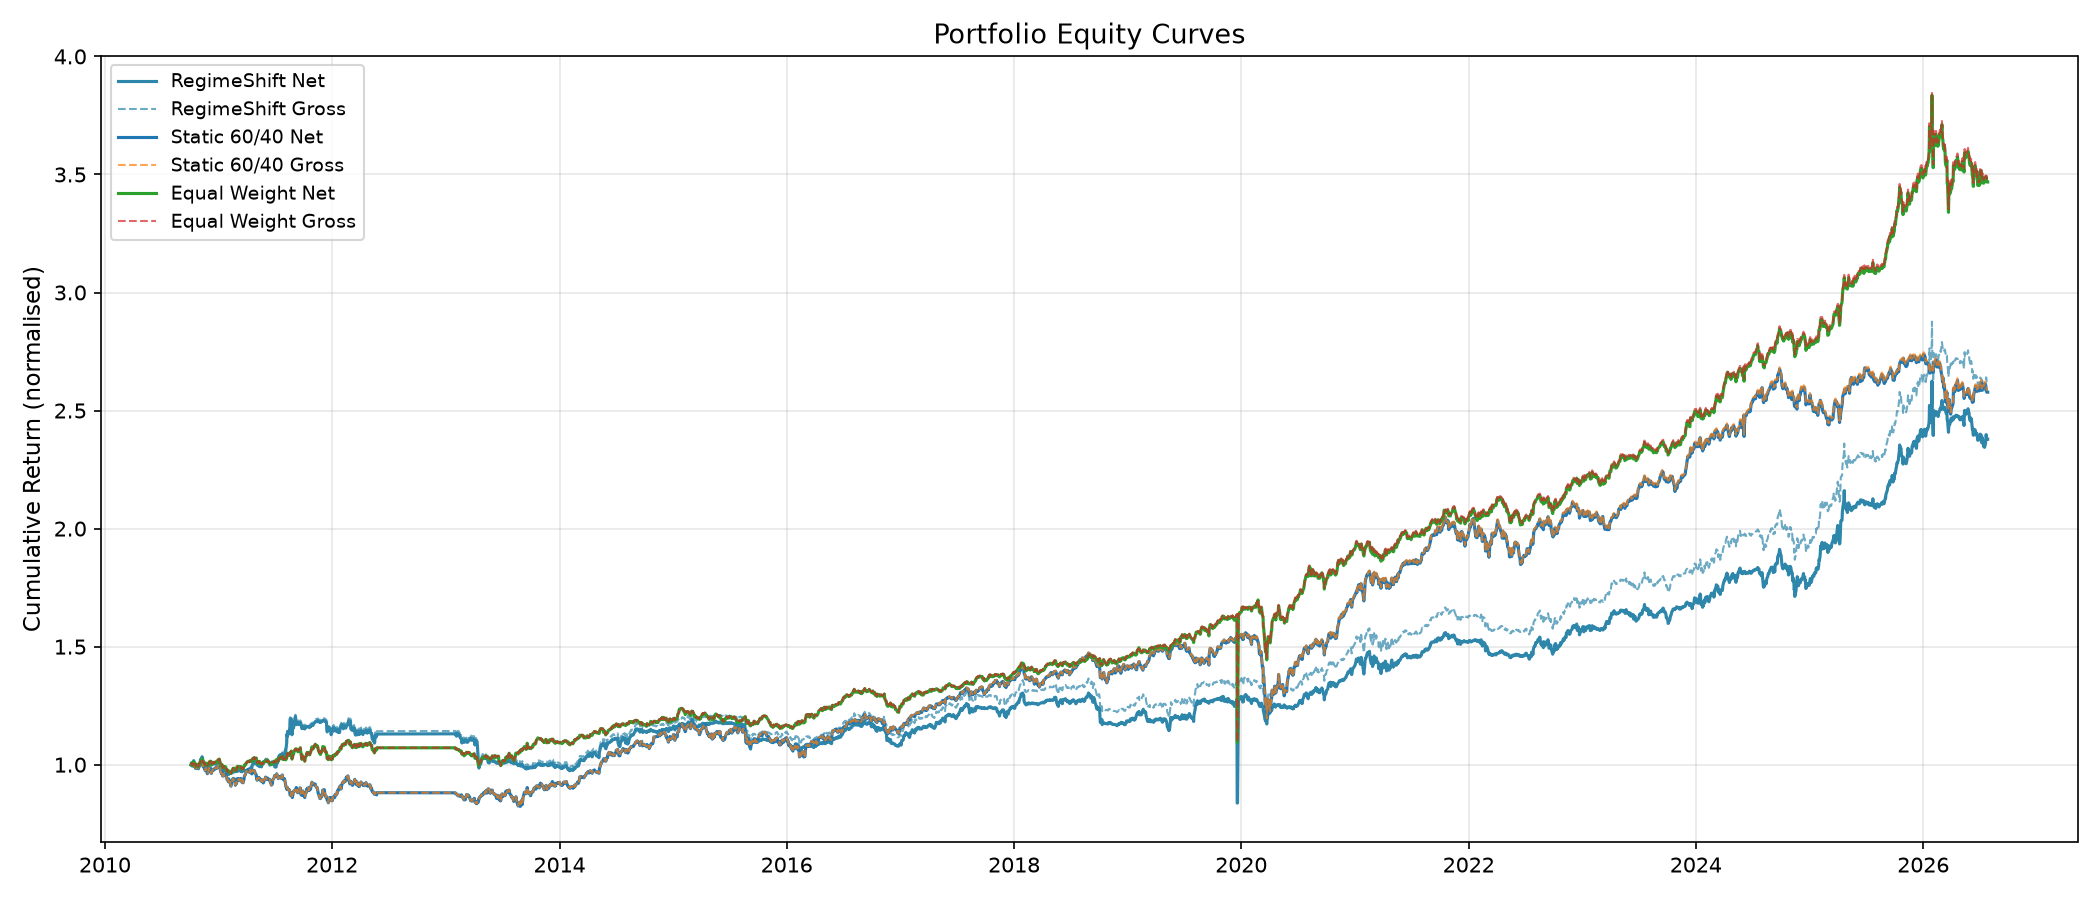

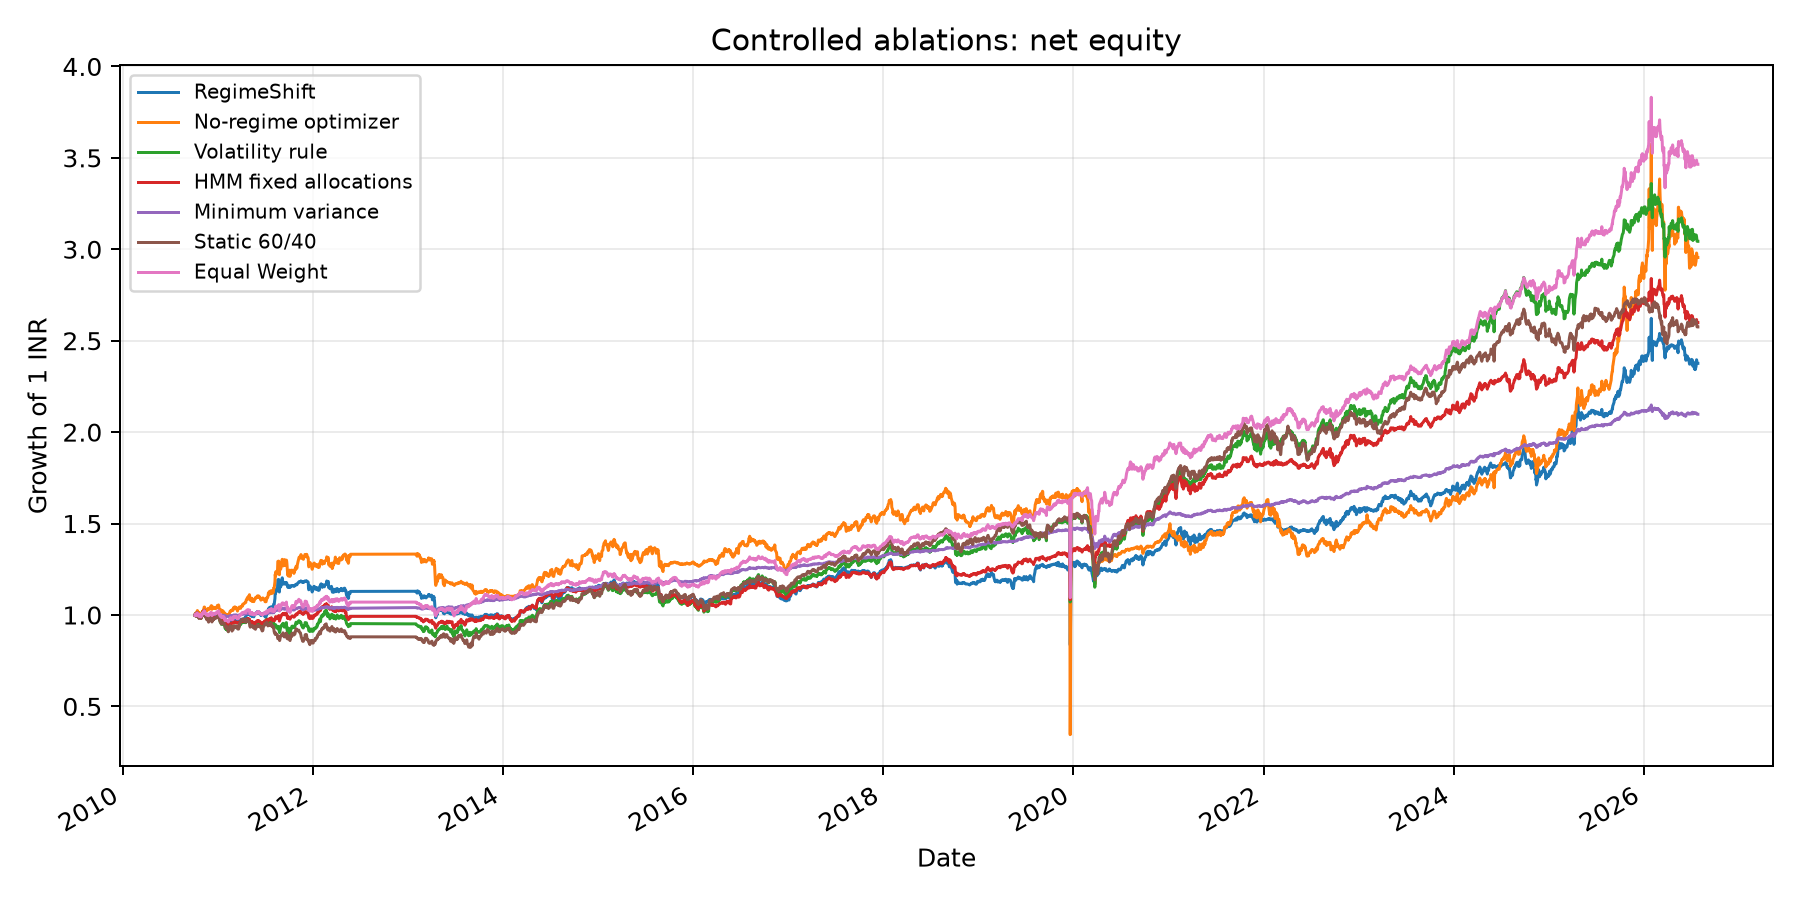

In [4]:
from IPython.display import Image, display
for name in ['equity_curves.png', 'drawdowns.png', 'portfolio_weights.png', 'regime_price_chart.png', 'transition_matrix.png', 'regime_probabilities.png']:
    print('submission artifact:', name)
for name in ['ablation_equity_curves.png', 'rolling_origin_sharpe.png', 'bootstrap_difference_distributions.png']:
    print('research artifact:', name)
display(Image(filename=str(submission / 'equity_curves.png')))
display(Image(filename=str(research / 'ablation_equity_curves.png')))


In [5]:
hmm = pd.read_csv(research / 'hmm_restart_summary.csv')
display(hmm)
print('Conclusion: negative benchmark and complexity findings remain visible.')


,hmm_fits,restarts_per_fit,converged_candidates,fallback_to_non_converged,mean_iterations,median_log_likelihood
0,178,3,534,0,200.0,-1841.792414


Conclusion: negative benchmark and complexity findings remain visible.
